In [10]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=["Month"], index_col="Month")

In [3]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


##### Questions
- What is the frequency of the observations? <br>
The observations are monthly.
<br><br>

- How many observations are there in the dataset? <br>
To know, you can print the length of the dataframe:

In [4]:
# Solution
print(len(df))

144


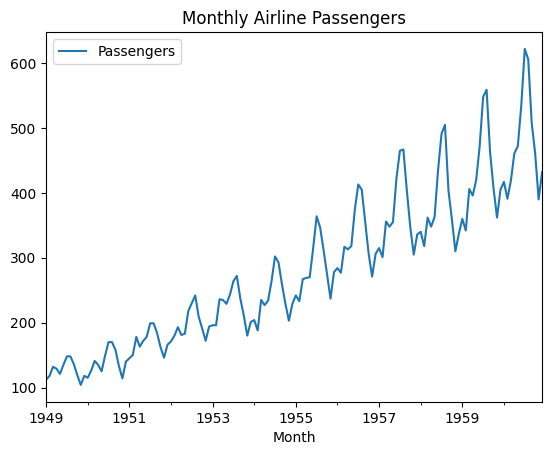

In [11]:
# Exercise 1: Solution
# Plot the time series
df.plot(title="Monthly Airline Passengers")
plt.show()

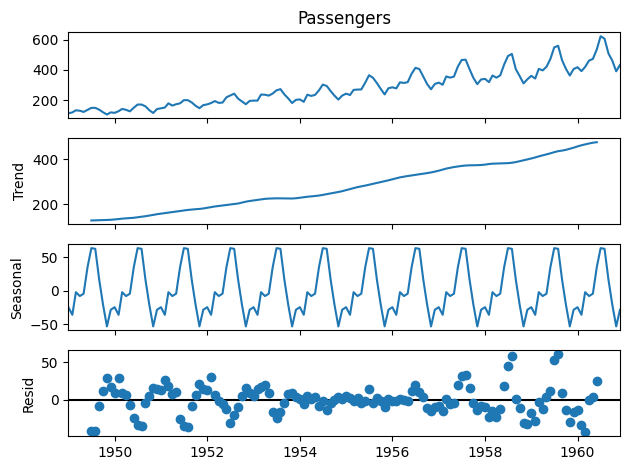

In [13]:
# Exercise 2
# Plot the components of the time series
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df["Passengers"])
result.plot()
plt.show()

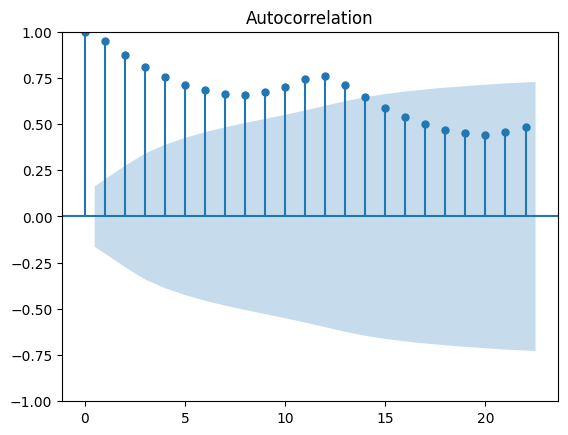

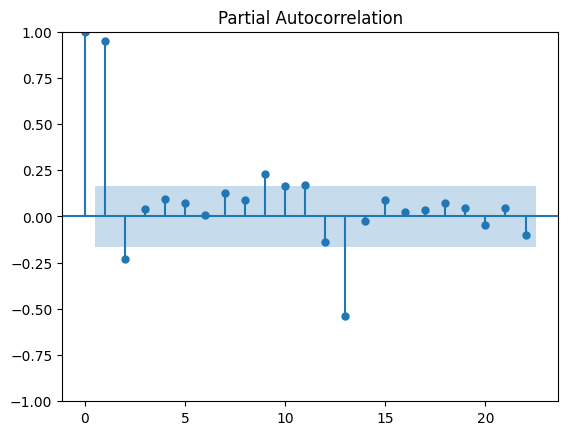

In [14]:
# Exercise 3
# Plot ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df["Passengers"])
plot_pacf(df["Passengers"])
plt.show()

In [19]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Passengers'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641


The p-value is > 0.05, meaning that the data is NOT stationary.

##### Questions
- What is stationarity?
- Is the time series stationary?
- What is the difference between ACF and PACF?

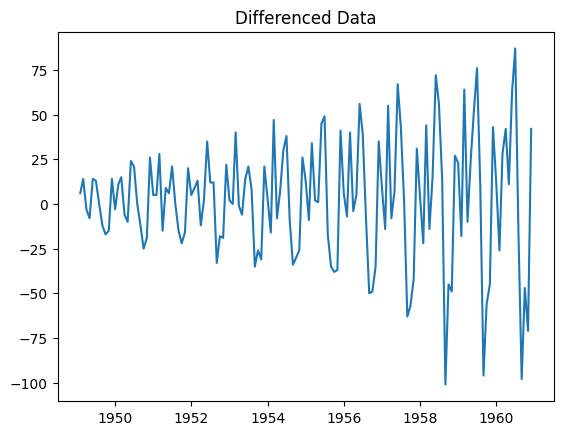

In [20]:
# Exercise 4
# If it is not already, make the time series stationary

df_diff = df.diff().dropna()

plt.plot(df_diff)
plt.title("Differenced Data")
plt.show()

In [21]:
result = adfuller(df_diff['Passengers'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -2.8292668241700047
p-value: 0.05421329028382478


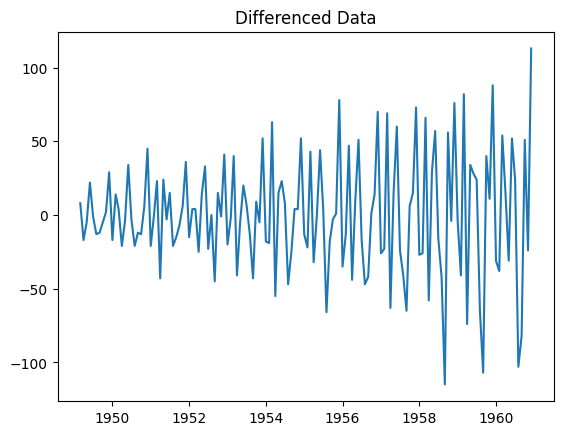

In [22]:
df_diff2 = df.diff().diff().dropna()
plt.plot(df_diff2)
plt.title("Differenced Data")
plt.show()

In [23]:
result = adfuller(df_diff2 ['Passengers'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -16.384231542468513
p-value: 2.7328918500142026e-29
